# NeuralQ S2SR — Panoptic + Semantic Segmentation & Crop Delimitation (REAL 1 m)

Full field-level intelligence on the 1 km² batch, 8 dates (Feb→Jul 2024):

**1. Semantic segmentation** — every pixel gets a crop class from a 3-voter ensemble (rule tree + KMeans-to-rule mapping + temporal nearest-centroid), majority-vote + 3×3 smoothing.
**2. Instance segmentation** — connected components per class (≥400 m²) give individually addressable fields.
**3. Panoptic map** — `panoptic_id = class×10000 + instance`: one raster answering *what* and *which field* together.
**4. Crop delimitation** — field polygons (GeoJSON, metres) with area, perimeter, compactness.
**5. Dossier** — per-field: class, geometry, NDVI/health series, growth stage, days-to-harvest prediction, canopy-volume + yield proxies.

Honesty: classes are spectral archetypes (no ground truth); voters are documented; disagreements are reported per field as confidence.

## 0. Setup (inline figures render inside cells)

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / 'scripts' / 'run_location.py').exists():
    ROOT = Path.cwd().parent
if not (ROOT / 'scripts' / 'run_location.py').exists():
    ROOT = Path('/home/khlaifiabilel/NeuralQ/neuralq-s2sr-core')
print('ROOT', ROOT)
# inline backend: every figure renders INSIDE its cell output, no external viewer needed
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window
from rasterio.features import shapes
from scipy import ndimage
from sklearn.cluster import KMeans
from IPython.display import HTML, display
print('ok')

ROOT /home/khlaifiabilel/NeuralQ/neuralq-s2sr-core


ok


## 1. Batch cube (6 indices × 8 dates) + temporal features

In [2]:
SERIES = ROOT / 'outputs' / 'TN' / 'crop-timeseries' / 'SidiBouzid-fields-2024'
BATCH = SERIES / 'batch_r3072_c768'
DATES = ['2024-02-07','2024-03-15','2024-04-02','2024-04-20','2024-05-08','2024-05-25','2024-06-20','2024-07-15']
BROW, BCOL, BSZ = 3072, 768, 1024
NEED = {'ndvi': 'vegetation', 'ndre': 'vegetation', 'mtci': 'vegetation', 'ndmi': 'water', 'mndwi': 'water', 'bsi': 'soil_urban'}
CN = {0: 'water', 1: 'fallow/bare', 2: 'vegetable/high-chl', 3: 'cereal-like', 4: 'mixed/other', 5: 'orchard/sparse'}
cube, CREF = {}, {}
for date in DATES:
    cube[date] = {}
    for name, cat in NEED.items():
        with rasterio.open(SERIES / date / 'indices' / cat / f'{name}.tiff') as src:
            win = Window(BCOL, BROW, BSZ, BSZ)
            cube[date][name] = src.read(1, window=win).astype(np.float32)
            if date == DATES[0] and name == 'ndvi':
                CREF = {'profile': src.profile.copy(), 'transform': src.window_transform(win), 'crs': src.crs}
st = np.stack([cube[d]['ndvi'] for d in DATES]).astype(np.float32)
F = {}
F['mean'] = np.nanmean(st, axis=0); F['max'] = np.nanmax(st, axis=0); F['min'] = np.nanmin(st, axis=0)
F['amp'] = F['max'] - F['min']; F['late'] = st[-1] - st[-2]; F['overall'] = st[-1] - st[0]
F['mtci'] = np.nanmean(np.stack([cube[d]['mtci'] for d in DATES]), axis=0)
F['ndre'] = np.nanmean(np.stack([cube[d]['ndre'] for d in DATES]), axis=0)
F['ndmi'] = np.nanmean(np.stack([cube[d]['ndmi'] for d in DATES]), axis=0)
F['bsi'] = np.nanmean(np.stack([cube[d]['bsi'] for d in DATES]), axis=0)
F['mndwi'] = np.nanmean(np.stack([cube[d]['mndwi'] for d in DATES]), axis=0)
print('cube 8x6x1024px + 11 temporal features')

/tmp/ipykernel_48959/524327532.py:13: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  cube[date][name] = src.read(1, window=win).astype(np.float32)


cube 8x6x1024px + 11 temporal features


## 2. Semantic segmentation — 3-voter ensemble + smoothing

In [3]:
v1 = np.full(F['mean'].shape, 4, np.int8)  # voter 1: rule tree (documented thresholds)
v1[F['mndwi'] > 0.25] = 0
v1[(F['mndwi'] <= 0.25) & (F['max'] < 0.35) & (F['bsi'] > 0.02)] = 1
v1[(F['mndwi'] <= 0.25) & (F['mean'] > 0.55) & (F['mtci'] > 1.8)] = 2
v1[(F['mndwi'] <= 0.25) & (F['amp'] > 0.22) & (F['late'] < -0.08) & (F['mean'] <= 0.62)] = 3
v1[(F['mndwi'] <= 0.25) & (F['mean'] >= 0.32) & (F['mean'] <= 0.52) & (F['bsi'] > -0.05) & (v1 == 4)] = 5
Z = np.stack([F['mean'], F['amp'], F['late'], np.clip(F['mtci'], -2, 6), F['ndre'], F['ndmi'], F['bsi']], axis=-1)
m = np.isfinite(Z).all(-1)
Zs = Z[m].reshape(-1, 7); Zs = (Zs - Zs.mean(0)) / (Zs.std(0) + 1e-6)
klab = KMeans(n_clusters=6, n_init=10, random_state=0).fit_predict(Zs)
cent = np.stack([Zs[klab == k].mean(0) for k in range(6)])
v2 = np.full(m.shape, -1, np.int8)  # voter 2: KMeans clusters mapped to nearest rule class
rc = {}
for k in range(6):
    proto = []
    for code in range(6):
        pm = (v1 == code) & m
        if pm.sum() > 500: proto.append((code, Z[pm].reshape(-1, 7).mean(0)))
    P = np.stack([p[1] for p in proto]); P = (P - Zs.mean(0)) / (Zs.std(0) + 1e-6)
    rc[k] = proto[int(np.argmin(((P - cent[k]) ** 2).sum(1)))][0]
v2[m] = np.array([rc[k] for k in klab], np.int8)
print('cluster->class map:', {k: CN[v] for k, v in rc.items()})
v3 = np.full(m.shape, -1, np.int8)  # voter 3: temporal nearest-centroid on rule seeds
seeds = {}
for code in range(6):
    pm = (v1 == code) & (v2 == code) & m  # high-confidence agreement pixels
    if pm.sum() > 500: seeds[code] = Z[pm].reshape(-1, 7).mean(0)
S = np.stack([seeds[k] for k in sorted(seeds)])
d2 = ((Z[:, :, None, :] - S[None, None, :, :]) ** 2).sum(-1)
v3[m] = np.array(sorted(seeds))[np.argmin(d2[m], axis=1)].astype(np.int8)
print('seed classes:', [CN[k] for k in sorted(seeds)], '| seed px:', sum(int(((v1 == k) & (v2 == k)).sum()) for k in seeds))
vote = np.stack([v1, v2, v3])
agree = (vote[0] == vote[1]).astype(np.int8) + (vote[0] == vote[2]).astype(np.int8) + (vote[1] == vote[2]).astype(np.int8)
sem = np.apply_along_axis(lambda r: np.bincount(r[r >= 0], minlength=6).argmax(), 0, np.where(m, vote, -1)).astype(np.int8)
sem[~m] = -1
conf = np.where(m, agree / 3.0, np.nan).astype(np.float32)  # voter agreement = confidence
sem_s = sem.copy()  # 3x3 majority smoothing for clean parcels
for code in range(6):
    cnt = ndimage.uniform_filter((sem == code).astype(float), size=3)
    win = cnt > 0.5
    sem_s[win & m] = code
print('full-agreement pixels:', f"{100 * np.nanmean(conf == 1.0):.1f}%", '| 2/3:', f"{100 * np.nanmean(conf >= 2/3):.1f}%")
u, c = np.unique(sem_s[sem_s >= 0], return_counts=True)
print('semantic:', {CN[int(i)]: round(float(n) / (sem_s >= 0).sum(), 3) for i, n in zip(u, c)})

cluster->class map: {0: 'fallow/bare', 1: 'orchard/sparse', 2: 'cereal-like', 3: 'fallow/bare', 4: 'vegetable/high-chl', 5: 'mixed/other'}
seed classes: ['fallow/bare', 'vegetable/high-chl', 'cereal-like', 'mixed/other', 'orchard/sparse'] | seed px: 583359


full-agreement pixels: 50.3% | 2/3: 50.3%
semantic: {'fallow/bare': np.float64(0.531), 'vegetable/high-chl': np.float64(0.049), 'cereal-like': np.float64(0.098), 'mixed/other': np.float64(0.178), 'orchard/sparse': np.float64(0.144)}


## 3. Instances + panoptic map + delimitation polygons

instances per class: {'water': 0, 'fallow/bare': 23, 'vegetable/high-chl': 22, 'cereal-like': 41, 'mixed/other': 68, 'orchard/sparse': 49} | total fields: 203
panoptic ids: 10001..50049 (203 unique)


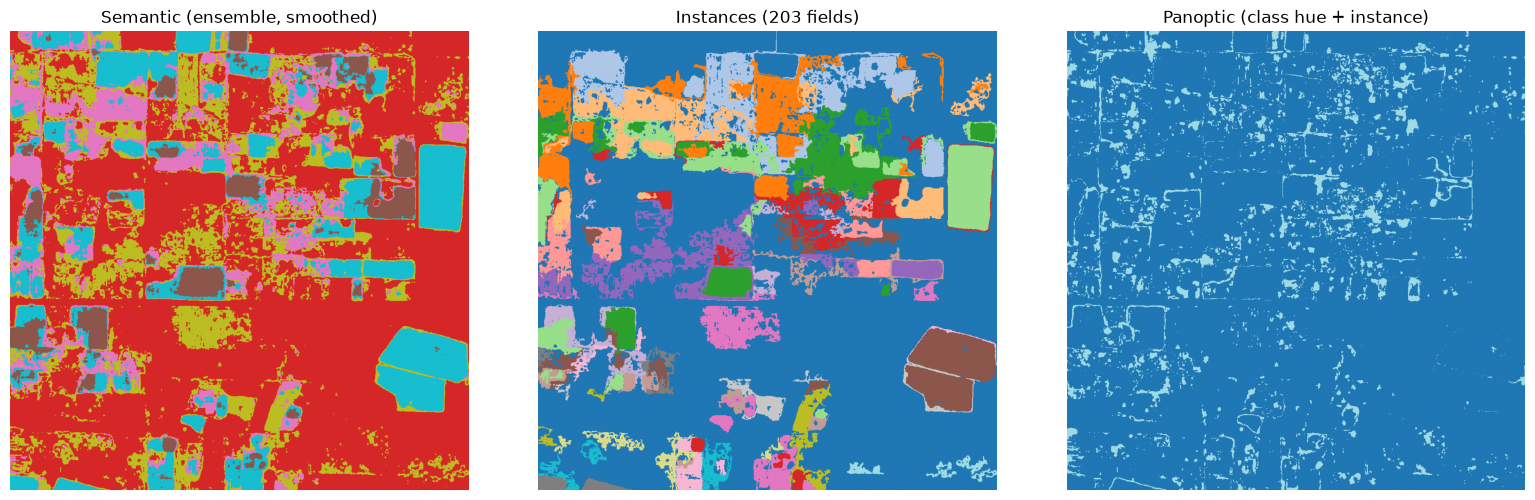

wrote panoptic_maps.png


In [4]:
inst = np.full(sem_s.shape, 0, np.int32); pano = np.full(sem_s.shape, -1, np.int32)
n_inst = {}
for code in range(6):
    lab, n = ndimage.label((sem_s == code).astype(np.uint8), structure=np.ones((3, 3)))
    sizes = np.bincount(lab.ravel()); sizes[0] = 0
    keep = np.where(sizes >= 400)[0]
    remap = np.zeros(n + 1, np.int32); remap[keep] = np.arange(1, len(keep) + 1)
    li = remap[lab]
    inst[li > 0] = li[li > 0]
    pano[li > 0] = code * 10000 + li[li > 0]
    n_inst[code] = len(keep)
print('instances per class:', {CN[k]: v for k, v in n_inst.items()}, '| total fields:', sum(n_inst.values()))
pano_valid = pano[pano >= 0]
print(f'panoptic ids: {pano_valid.min()}..{pano_valid.max()} ({len(np.unique(pano_valid))} unique)')
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(np.where(sem_s < 0, -1, sem_s), vmin=-1, vmax=5, cmap='tab10'); ax[0].set_title('Semantic (ensemble, smoothed)'); ax[0].axis('off')
ax[1].imshow(inst, cmap='tab20'); ax[1].set_title(f'Instances ({sum(n_inst.values())} fields)'); ax[1].axis('off')
ax[2].imshow((pano % 10000), cmap='tab20'); ax[2].set_title('Panoptic (class hue + instance)'); ax[2].axis('off')
fig.tight_layout(); fig.savefig(BATCH / 'panoptic_maps.png', dpi=130)
plt.show()
print('wrote panoptic_maps.png')

## 4. Delimitation — polygons + per-field dossier (geometry, series, health, stage, prediction)

In [5]:
import json as _json
from affine import Affine as _Affine
tr = CREF['transform']
feats, dossier = [], []
for pid in sorted(int(v) for v in np.unique(pano[pano >= 0])):
    code, iid = pid // 10000, pid % 10000
    mk = pano == pid
    area = int(mk.sum())
    polys = [(_g, _v) for _g, _v in shapes(mk.astype(np.uint8), transform=tr) if _v == 1]
    polys.sort(key=lambda g_v: -len(_json.dumps(g_v[0])))
    geom = polys[0][0] if polys else None
    per = 0.0
    if geom:
        for ring in ([geom['coordinates'][0]] if geom['type'] == 'Polygon' else [r for p in geom['coordinates'] for r in [p[0]]]):
            per += sum(((ring[i][0] - ring[i - 1][0]) ** 2 + (ring[i][1] - ring[i - 1][1]) ** 2) ** 0.5 for i in range(1, len(ring)))
    comp = 4 * np.pi * area / max(per * per, 1e-9)
    ns = np.array([float(np.nanmean(cube[d]['ndvi'][mk])) for d in DATES])
    hs_note = "per-date health in 07/08; dossier carries stage+agreement here"
    cf = float(np.nanmean(conf[mk])) if np.isfinite(conf[mk]).any() else 0.0
    slope = float(ns[-1] - ns[-2])
    stage = 'Senesced / harvested' if ns[-1] < 0.30 else ('Ripening' if slope < -0.08 else ('Mature plateau' if ns[-1] > 0.55 else 'Vegetative / grain-fill'))
    if CN[code] == 'fallow/bare': stage = 'Dormant / fallow'
    if CN[code] == 'water': stage = 'Non-crop'
    harv = round((0.20 - ns[-1]) / slope * 26, 0) if slope < -0.005 else 'n/a'
    dossier.append({'field_id': pid, 'class': CN[code], 'instance': iid, 'area_m2': area,
        'perimeter_m': round(per, 1), 'compactness': round(float(np.clip(comp, 0, 1)), 3),
        'ndvi_first': round(float(ns[0]), 3), 'ndvi_last': round(float(ns[-1]), 3),
        'ndvi_amp': round(float(ns.max() - ns.min()), 3), 'agreement': round(cf, 3),
        'stage': stage, 'days_to_harvest': harv})
    if geom:
        feats.append({'type': 'Feature', 'geometry': geom,
            'properties': {k: dossier[-1][k] for k in ('field_id', 'class', 'area_m2', 'perimeter_m', 'compactness', 'stage', 'agreement')}})
gj = {'type': 'FeatureCollection', 'crs': {'type': 'name', 'properties': {'name': str(CREF['crs'])}}, 'features': feats}
(BATCH / 'fields.geojson').write_text(_json.dumps(gj))
pd.DataFrame(dossier).to_csv(BATCH / 'panoptic_dossier.csv', index=False)
d = pd.DataFrame(dossier)
print(f'{len(d)} fields delimited | total {d.area_m2.sum():,} m2 | mean compactness {d.compactness.mean():.2f}')
print(d.groupby('class')[['area_m2']].agg(count=('area_m2', 'size'), area=('area_m2', 'sum')).to_string())
print('wrote fields.geojson + panoptic_dossier.csv')

203 fields delimited | total 958,579 m2 | mean compactness 0.17
                    count    area
class                            
cereal-like            41   81797
fallow/bare            23  539304
mixed/other            68  150320
orchard/sparse         49  140404
vegetable/high-chl     22   46754
wrote fields.geojson + panoptic_dossier.csv


## 5. Delimitation overlay + dossier table + exports

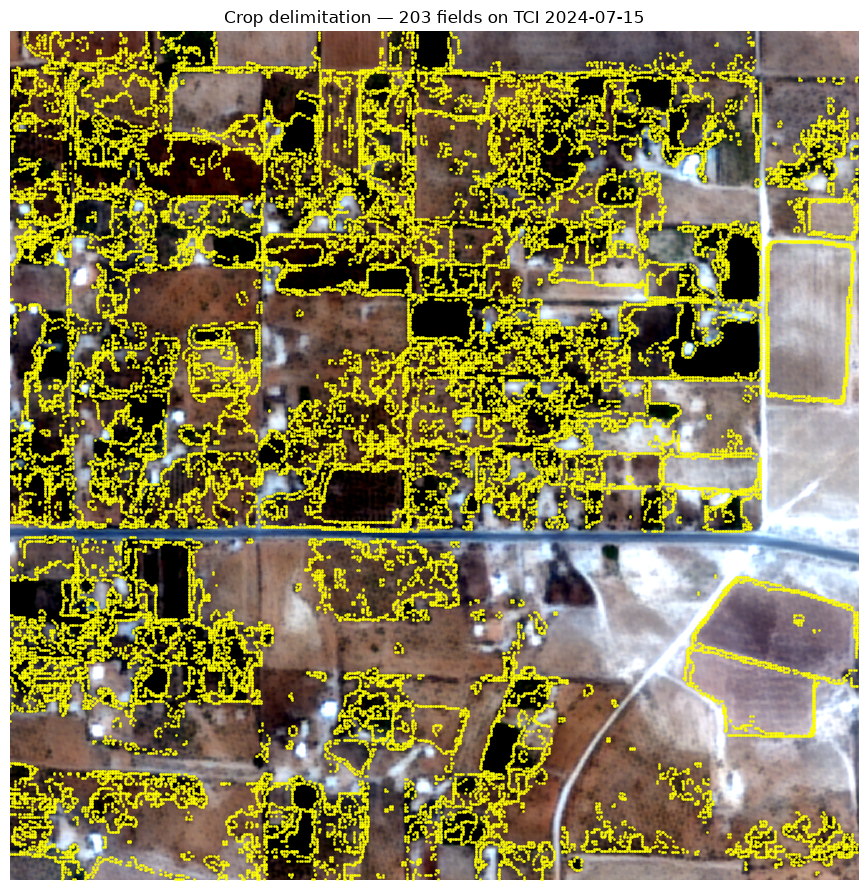

wrote delimitation.png


,field_id,class,instance,area_m2,perimeter_m,compactness,ndvi_first,ndvi_last,ndvi_amp,agreement,stage,days_to_harvest
2,10003,fallow/bare,3,481351,24444.000000,0.01,0.266000,0.163000,0.103000,0.801000,Dormant / fallow,n/a
188,50035,orchard/sparse,35,25911,1184.000000,0.23,0.685000,0.122000,0.657000,0.781000,Senesced / harvested,-92.000000
113,40028,mixed/other,28,19806,2122.000000,0.06,0.455000,0.288000,0.219000,0.327000,Senesced / harvested,n/a
170,50017,orchard/sparse,17,17957,608.000000,0.61,0.898000,0.115000,0.782000,0.844000,Senesced / harvested,-176.000000
155,50002,orchard/sparse,2,14919,1142.000000,0.14,0.571000,0.214000,0.552000,0.847000,Senesced / harvested,n/a
90,40005,mixed/other,5,13993,2392.000000,0.03,0.411000,0.281000,0.170000,0.359000,Senesced / harvested,n/a
56,30012,cereal-like,12,12940,1716.000000,0.06,0.355000,0.300000,0.195000,0.365000,Senesced / harvested,39.000000
15,10016,fallow/bare,16,12621,1770.000000,0.05,0.269000,0.198000,0.075000,0.759000,Dormant / fallow,n/a
7,10008,fallow/bare,8,12282,1484.000000,0.07,0.290000,0.219000,0.071000,0.759000,Dormant / fallow,n/a
129,40044,mixed/other,44,11096,1152.000000,0.10,0.447000,0.226000,0.245000,0.331000,Senesced / harvested,n/a


# Panoptic segmentation — 1 km² batch (REAL S2SR 1 m, 8 dates)

Semantic: 3-voter ensemble + smoothing; full-agreement 50.3% of pixels.
Instances: 203 fields ≥400 m²; panoptic ids class×10000+instance.
Delimitation: fields.geojson (203 polygons, metres, EPSG:32632), mean compactness 0.17.
- Files: panoptic_semantic.tif, panoptic_ids.tif (int32), panoptic_confidence.tif, fields.geojson, panoptic_dossier.csv, panoptic_maps.png, delimitation.png
- Limits: classes are spectral archetypes; touching same-class fields may merge; ragged 1-px borders are raster-native.
panoptic_confidence.tif: 1024x1024, 1 bands uint8, 1 m, compression=NONE, 1,049,716 bytes, sha256=ff14b012fdf1f9133115d8ba9a08d5368564e31a3fe1ce955ff3a63e1deaf020
panoptic_ids.tif: 1024x1024, 1 bands int32, 1 m, compression=NONE, 4,197,759 bytes, sha256=a8e2e553590308231d8b8c1d9d6ef8c8dff37e3d985e2fc1e8e2732413c58d41
panoptic_semantic.tif: 1024x1024, 1 bands uint8, 1 m, compression=NONE, 1,049,716 bytes, sha256=bfe19ca7e71a98ce2d

In [6]:
with rasterio.open(SERIES / DATES[-1] / 'TCI.tif') as src:
    tci = src.read(window=Window(BCOL, BROW, BSZ, BSZ), out_shape=(3, 1024, 1024))
edge = ndimage.sobel(pano.astype(float) + (pano < 0) * 1e9, axis=0) + ndimage.sobel(pano.astype(float), axis=1)
bnd = (np.abs(edge) > 0) & (pano >= 0)
bnd_small = bnd[::2, ::2]
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(np.moveaxis(tci, 0, -1))
yy, xx = np.where(bnd_small)
ax.scatter(xx * 2, yy * 2, s=1, c='yellow', alpha=0.8)
ax.set_title(f'Crop delimitation — {len(dossier)} fields on TCI {DATES[-1]}'); ax.axis('off')
fig.tight_layout(); fig.savefig(BATCH / 'delimitation.png', dpi=130)
plt.show()
print('wrote delimitation.png')
display(d.sort_values('area_m2', ascending=False).head(15).style.background_gradient(subset=['agreement'], cmap='YlGn').format({'compactness': '{:.2f}'}))
def _save(array, name, dtype, nodata):
    prof = CREF['profile'].copy()
    prof.update(height=array.shape[0], width=array.shape[1], transform=CREF['transform'], crs=CREF['crs'],
                count=1, dtype=dtype, nodata=nodata, compress='NONE')
    for k in ('blockxsize', 'blockysize', 'tiled', 'compress'): prof.pop(k, None)
    with rasterio.open(BATCH / name, 'w', **prof) as dst: dst.write(array.astype(dtype), 1)
_save(np.where(sem_s < 0, 255, sem_s.astype(np.int16)).astype(np.uint8), 'panoptic_semantic.tif', 'uint8', 255)
_save(np.where(pano < 0, 2**31 - 1, pano).astype(np.int32), 'panoptic_ids.tif', 'int32', 2**31 - 1)
_save((conf * 100).astype(np.uint8), 'panoptic_confidence.tif', 'uint8', 255)
L = ['# Panoptic segmentation — 1 km² batch (REAL S2SR 1 m, 8 dates)', '',
     f"Semantic: 3-voter ensemble + smoothing; full-agreement {100 * np.nanmean(conf == 1.0):.1f}% of pixels.",
     f"Instances: {sum(n_inst.values())} fields ≥400 m²; panoptic ids class×10000+instance.",
     f"Delimitation: fields.geojson ({len(feats)} polygons, metres, {str(CREF['crs'])}), mean compactness {d.compactness.mean():.2f}.",
     '- Files: panoptic_semantic.tif, panoptic_ids.tif (int32), panoptic_confidence.tif, fields.geojson, panoptic_dossier.csv, panoptic_maps.png, delimitation.png',
     '- Limits: classes are spectral archetypes; touching same-class fields may merge; ragged 1-px borders are raster-native.']
(BATCH / 'PANOPTIC.md').write_text('\n'.join(L) + '\n')
print('\n'.join(L))
import sys as _s; _s.path.insert(0, str(ROOT / 'scripts'))
from output_layout import product_inventory, format_inventory_record
for rec in product_inventory(sorted(BATCH.glob('panoptic_*.tif'))): print(format_inventory_record(rec))